## Задание 2: Деконволюция
#### Войт Руслан 417 группа

Последний день сдачи - 28 апреля 2026 года (материалы направлять в тг @yakefu)

### Описание задачи:
Требуется написать программу, реализующую метод обращения свёртки (деконволюции) изображений через минимизацию регуляризирующего функционала. Выбор нормы невязки, стабилизатора на усмотрение студента. Рекомендуемый стабилизатор — функционал полной вариации, либо функционал полной обобщённой вариации. Рекомендуемое количество итераций — 100.

Требования к программе

* Язык программирования: Python 3. На системе для тестирования установлен Python 3 с дополнительными пакетами numpy, scipy, scikit-image, opencv-python (конкретные версии смотрите на основной странице курса).
* Интерфейс: программа должна поддерживать интерфейс командной строки со строгим соблюдением формата входных данных. Входные параметры при тестировании программы будут всегда корректны, валидация входных параметров не требуется.
* Формат изображений: все входные изображения будут в формате 24-bit BMP. Сами изображения — в градациях серого, т.е. красная, зелёная и синяя компонента совпадают.
* Допустимо и рекомендуется использовать платформенно-независимые библиотеки для чтения и сохранения изображений, для вспомогательных операций (векторные операции, свёртка), для разбора параметров командной строки.
* Недопустимо использование библиотечных функций, решающих задачу целиком.
* Недопустимо выполнение побочных действий, таких как создание временных файлов, ожидание ввода и отладочный вывод в консоль, открытие диалоговых окон и т.д.

### Критерии оценки:
Задание принимается, если качество результата выше, чем качество исходного изображения относительно эталона по метрике PSNR.

### Рекомендации:
При тестировании будут использоваться изображения с гауссовским шумом со стандартным отклонением в диапазоне [0, 20] и со следующими ядрами размытия: фильтр Гаусса (параметр от 0.5 до 5), круг (радиус от 0.5 до 5), а также реальные сложные ядра, возникающие при движении (motion blur). Рекомендуется самостоятельно смоделировать различные ситуации и найти оптимальные параметры в зависмости от уровня шума.

In [1]:
import cv2
import pandas as pd
from skimage import io
import numpy as np
import matplotlib.pyplot as plt

Сперва посмотрим на исходные изображения

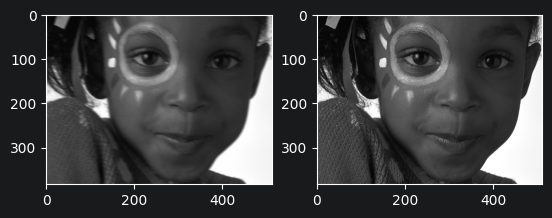

In [2]:
reference = io.imread('task_testdata/reference.bmp')
blurred = io.imread('task_testdata/blurred.bmp')

plt.subplot(121)
plt.imshow(blurred)
plt.subplot(122)
plt.imshow(reference)
plt.show()


Перед непосредственным созданием алгоритма деконволюции следует понять одно - нам важен алгоритм проверки качества деконволюции. Очевидно, что для этого потребуется метрика качества PSNR. Но только метрики на одном изображении недостаточно, поэтому создадим бенчмарк из нескольких изображений, на которых будем проверять качество деконволюции.

Для этого обратимся к известным датасетам Kodak и UCS-SIPI. В них есть изображения как в высоком, так и в низком разрешении с разными типами границ. Я отобрал несколько изображений из этих датасетов и перевел их в 24bmp-формат в градациях серого ровно как в условии задачи. Эти изображения хранятся в папке `benchmark_sources_bmp`. На самом деле изображений получилось достаточно много, поэтому я выберу из них только 10 для тестирования и подбора параметров, остальные же возможно пригодятся для дальнейших экспериментов.

## Зашумление
Научимся зашумлять изображения. Для этого реализуем все необходимые функции для создания гауссовского шума и фильтров размытия. В дальнейшем эти функции будут использоваться для создания тестовых изображений, на которых мы будем проверять качество деконволюции

In [3]:
def normalize_kernel(kernel: np.ndarray) -> np.ndarray:
    kernel = np.asarray(kernel, dtype=np.float32)
    total = float(kernel.sum())
    if total <= 0.0:
        raise ValueError("Kernel sum must be positive.")
    return kernel / total


def gaussian_kernel(size: int, sigma: float) -> np.ndarray:
    size = size + 1 - size % 2
    radius = size // 2
    y, x = np.mgrid[-radius : radius + 1, -radius : radius + 1]
    kernel = np.exp(-(x * x + y * y) / (2.0 * sigma * sigma))
    return normalize_kernel(kernel)


def disk_kernel(size: int, radius: float) -> np.ndarray:
    size = size + 1 - size % 2
    center = size // 2
    y, x = np.mgrid[0:size, 0:size]
    distances = np.sqrt((x - center) ** 2 + (y - center) ** 2)
    kernel = (distances <= radius).astype(np.float32)
    return normalize_kernel(kernel)


def motion_kernel(size: int, angle_deg: float, length: float, thickness: float) -> np.ndarray:
    size = size + 1 - size % 2
    canvas = np.zeros((size, size), dtype=np.float32)
    center = (size - 1) / 2.0
    half = max(0.5, length / 2.0)
    angle = np.deg2rad(angle_deg)
    dx = half * np.cos(angle)
    dy = half * np.sin(angle)
    pt1 = (int(round(center - dx)), int(round(center - dy)))
    pt2 = (int(round(center + dx)), int(round(center + dy)))
    cv2.line(canvas, pt1, pt2, color=1.0, thickness=max(1, int(round(thickness))), lineType=cv2.LINE_AA)
    return normalize_kernel(canvas)

In [4]:
def add_gaussian_noise(image: np.ndarray, noise_level: float, seed: int) -> np.ndarray:
    rng = np.random.default_rng(seed)
    noise = rng.normal(loc=0.0, scale=noise_level, size=image.shape).astype(np.float32)
    return np.clip(image + noise, 0.0, 255.0)

In [5]:
def apply_blur(image: np.ndarray, kernel: np.ndarray) -> np.ndarray:
    return cv2.filter2D(image, ddepth=-1, kernel=kernel, borderType=cv2.BORDER_REFLECT)

Также расчет метрики PSNR для оценки качества деконволюции

In [6]:
def compute_psnr(reference: np.ndarray, candidate: np.ndarray) -> float:
    mse = float(np.mean((reference - candidate) ** 2))
    if mse <= 0.0:
        return float("inf")
    return 10.0 * np.log10((255.0 ** 2) / mse)

Вспомогательный код для загрузки изображений

In [7]:
from pathlib import Path

def load_grayscale_bmp(path: Path) -> np.ndarray:
    image = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    if image is None:
        raise FileNotFoundError(f"Could not read image: {path}")
    return image.astype(np.float32)

def normalize_kernel(kernel: np.ndarray) -> np.ndarray:
    kernel = np.asarray(kernel, dtype=np.float32)
    total = float(kernel.sum())
    if total <= 0.0:
        raise ValueError("Kernel sum must be positive.")
    return kernel / total


def save_grayscale_bmp(path: Path, image: np.ndarray) -> None:
    image = np.clip(np.rint(image), 0, 255).astype(np.uint8)
    image_rgb = np.repeat(image[:, :, None], 3, axis=2)
    path.parent.mkdir(parents=True, exist_ok=True)
    if not cv2.imwrite(str(path), image_rgb):
        raise OSError(f"Could not write image: {path}")

def save_kernel_preview(path: Path, kernel: np.ndarray) -> None:
    scaled = kernel / max(float(kernel.max()), 1e-8)
    preview = np.clip(np.rint(scaled * 255.0), 0, 255).astype(np.uint8)
    save_grayscale_bmp(path, preview)

Пример создания зашумленного и размытого изображения

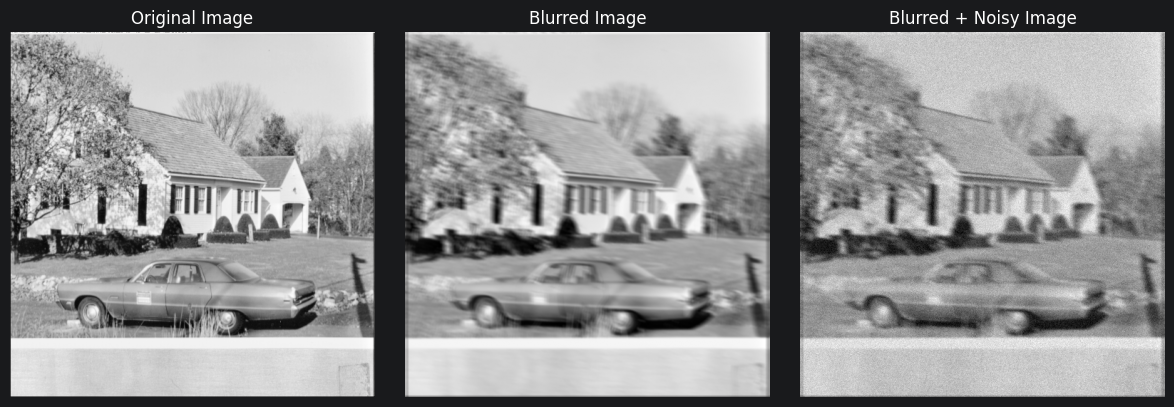

In [8]:
image = load_grayscale_bmp(Path("benchmark/house.bmp"))
kernel = motion_kernel(size=11, angle_deg=13, length=9, thickness=2)
blurred_image = apply_blur(image, kernel)
noisy_blurred_image = add_gaussian_noise(blurred_image, noise_level=10.0, seed=42)

save_grayscale_bmp(Path("test_images/blurred_noisy_image_01.bmp"), noisy_blurred_image)
save_kernel_preview(Path("test_images/kernel_preview_01.bmp"), kernel)

fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(image, cmap='gray')
ax[0].set_title("Original Image")
ax[1].imshow(blurred_image, cmap='gray')
ax[1].set_title("Blurred Image")
ax[2].imshow(noisy_blurred_image, cmap='gray')
ax[2].set_title("Blurred + Noisy Image")
for a in ax:
    a.axis('off')
plt.tight_layout()
plt.show()

Таким образом считаем, что оригинальное изображение проходит сначала размытие, а потом зашумление. Именно это зашумление мешает нам восстановить изображение, зная точные параметры ядра размытия. Поэтому наша задача - найти оптимальные параметры деконволюции, которые позволят нам максимально приблизиться к эталонному изображению, несмотря на наличие шума

In [9]:
BENCHMARK_PATH = Path("large_benchmark")
IMG_PATH = Path("benchmark")

KERNEL_PRESETS = [
    {"name": "gaussian_s1p0", "type": "gaussian", "size": 9, "sigma": 1.0},
    {"name": "gaussian_s2p5", "type": "gaussian", "size": 15, "sigma": 2.5},
    {"name": "disk_r2p0", "type": "disk", "size": 9, "radius": 2.0},
    {"name": "disk_r4p0", "type": "disk", "size": 15, "radius": 4.0},
    {"name": "motion_l9_a15", "type": "motion", "size": 19, "length": 9.0, "angle": 15.0, "thickness": 1.0},
    {"name": "motion_l13_a35", "type": "motion", "size": 25, "length": 13.0, "angle": 35.0, "thickness": 2.0},
    {"name": "motion_l17_a75", "type": "motion", "size": 29, "length": 17.0, "angle": 75.0, "thickness": 2.0},
]

def build_kernel(spec: dict[str, float | str]) -> np.ndarray:
    if spec["type"] == "gaussian":
        return gaussian_kernel(size=int(spec["size"]), sigma=float(spec["sigma"]))
    if spec["type"] == "disk":
        return disk_kernel(size=int(spec["size"]), radius=float(spec["radius"]))
    if spec["type"] == "motion":
        return motion_kernel(
            size=int(spec["size"]),
            angle_deg=float(spec["angle"]),
            length=float(spec["length"]),
            thickness=float(spec["thickness"]),
        )
    raise ValueError(f"Unsupported kernel type: {spec['type']}")


### С чем сравнимся?
Мы построили функцию, вычисляющую PSNR и теперь нам надо понять, какая метрика для my result, что есть в приложенном архиве

In [10]:
reference = load_grayscale_bmp(Path("task_testdata/reference.bmp"))
my_result = load_grayscale_bmp(Path("task_testdata/my_result.bmp"))
psnr_value = compute_psnr(reference, my_result)
print(f"PSNR between reference and my result: {psnr_value:.2f} dB")

PSNR between reference and my result: 33.48 dB


При этом сами изображения очевидно не совпадают

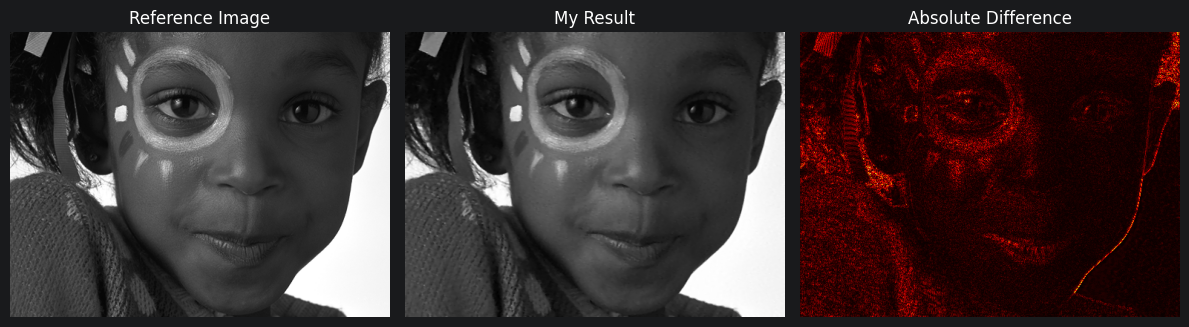

In [11]:
fig, ax = plt.subplots(1, 3, figsize=(12, 6))
diff = np.abs(reference - my_result)
ax[0].imshow(reference, cmap='gray')
ax[0].set_title("Reference Image")
ax[1].imshow(my_result, cmap='gray')
ax[1].set_title("My Result")
ax[2].imshow(diff, cmap='hot')
ax[2].set_title("Absolute Difference")
for a in ax:
    a.axis('off')
plt.tight_layout()
plt.show()

Признаться честно, от последней картинки мне стало страшно :)

In [12]:
from tqdm import tqdm

for img_path in tqdm(IMG_PATH.glob("*.bmp"), desc="Building kernels"):
    image = load_grayscale_bmp(img_path)
    for kernel_spec in KERNEL_PRESETS:
        kernel = build_kernel(kernel_spec)
        blurred_image = apply_blur(image, kernel)
        noisy_blurred_image = add_gaussian_noise(blurred_image, noise_level=10.0, seed=42)

        subdir = BENCHMARK_PATH / img_path.stem / kernel_spec["name"]
        save_grayscale_bmp(subdir / "reference.bmp", image)
        save_grayscale_bmp(subdir / "blurred.bmp", noisy_blurred_image)
        save_kernel_preview(subdir / "kernel.bmp", kernel)

Building kernels: 9it [00:01,  6.33it/s]


## Деконволюция. Метод TV + L2

Здесь мы используем функционал полной вариации TV в качестве стабилизатора и L2-норму для невязки, как это было на лекциях

In [13]:
def gradient_forward(image: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    grad_x = np.zeros_like(image, dtype=np.float32)
    grad_y = np.zeros_like(image, dtype=np.float32)
    grad_x[:, :-1] = image[:, 1:] - image[:, :-1]
    grad_y[:-1, :] = image[1:, :] - image[:-1, :]
    return grad_x, grad_y

Функция расчета дивергенции понадобится, как сопряженный оператор к градиенту для реализации метода TV

In [14]:
def divergence(px: np.ndarray, py: np.ndarray) -> np.ndarray:
    div = np.zeros_like(px, dtype=np.float32)
    div[:, 0] = px[:, 0]
    div[:, 1:-1] = px[:, 1:-1] - px[:, :-2]
    div[:, -1] = -px[:, -2]
    div[0, :] += py[0, :]
    div[1:-1, :] += py[1:-1, :] - py[:-2, :]
    div[-1, :] += -py[-2, :]
    return div

Сделаем тюнинг параметров позже, а пока просто сделаем такую функцию-заглушку

In [20]:
def choose_parameters(noise_level: float) -> tuple[float, int]:
    if noise_level <= 2.0:
        return 0.45, 140
    if noise_level <= 5.0:
        return 0.75, 120
    if noise_level <= 9.0:
        return 1.10, 110
    if noise_level <= 14.0:
        return 1.50, 100
    return 1.90, 90

Учтем особенности граничных условий при свертке, чтобы не было артефактов на границах изображения. Для этого используем режим "symm" в функции convolve2d из scipy, который обеспечивает симметричное отражение границ

In [15]:
from scipy.signal import convolve2d
def convolve_reflect(image: np.ndarray, kernel: np.ndarray) -> np.ndarray:
    return convolve2d(image, kernel, mode="same", boundary="symm").astype(np.float32)

In [16]:
base_config = {
    "tau": 0.2,
    "sigma": 0.4,
    "theta": 1.0,
    "lambda_tv": 1,
    "iterations": 100
}

In [17]:
def deconvolve_tv(blurred: np.ndarray, kernel: np.ndarray, config: dict) -> np.ndarray:
    kernel = normalize_kernel(kernel)
    kernel_flipped = kernel[::-1, ::-1]

    tau = config["tau"]
    sigma = config["sigma"]
    lambda_tv = config["lambda_tv"]
    iterations = config["iterations"]
    theta = config["theta"]

    x = blurred.copy()
    x_bar = x.copy()
    px = np.zeros_like(blurred, dtype=np.float32)
    py = np.zeros_like(blurred, dtype=np.float32)

    for _ in range(iterations):
        grad_x, grad_y = gradient_forward(x_bar)
        px += sigma * grad_x
        py += sigma * grad_y

        norms = np.maximum(1.0, np.sqrt(px * px + py * py) / lambda_tv)
        px /= norms
        py /= norms

        blurred_estimate = convolve_reflect(x, kernel)
        data_grad = convolve_reflect(blurred_estimate - blurred, kernel_flipped)
        x_new = np.clip(x - tau * (data_grad - divergence(px, py)), 0.0, 255.0)
        x_bar = x_new + theta * (x_new - x)
        x = x_new

    return x

Пример использования функции деконволюции на одном из тестовых изображений

In [27]:
reference = load_grayscale_bmp(Path("task_testdata/reference.bmp"))
blurred = load_grayscale_bmp(Path("task_testdata/blurred.bmp"))
kernel = load_grayscale_bmp(Path("task_testdata/kernel.bmp"))

estimated = deconvolve_tv(blurred, kernel, base_config)
psnr_value = compute_psnr(reference, estimated)
print(f"PSNR of deconvolution result: {psnr_value:.2f} dB")
blurred_psnr = compute_psnr(reference, blurred)
print(f"PSNR of blurred image: {blurred_psnr:.2f} dB")

PSNR of deconvolution result: 30.69 dB
PSNR of blurred image: 28.42 dB


Видим, что деконволюция уже дает заметное улучшение по сравнению с зашумленным и размытым изображением, но все еще сильно не достигает эталона. Возможно стоит лучше подобрать параметры или попробовать другой стабилизатор

## Подбор параметров
Проведем серию экспериментов с разными параметрами и посмотрим, как они влияют на качество деконволюции. Сначала на референсном изображении. Применим Байесовскую оптимизацию для подбора параметров

In [18]:
from skopt import gp_minimize
from skopt.space import Real, Integer
from skopt.utils import use_named_args

In [42]:
search_space = [
    Real(0.1, 3.0, name="lambda_tv"),
    Real(0.01, 1.0, name="tau"),
    Real(0.1, 3.0, name="sigma"),
    Real(0.1, 3.0, name="theta"),
    Integer(75, 100, name="iterations"),
]

@use_named_args(search_space)
def objective(**params):
    config = base_config.copy()
    config.update(params)
    estimated = deconvolve_tv(blurred, kernel, config)
    psnr_value = compute_psnr(reference, estimated)
    print(psnr_value)
    return -psnr_value  # Максимизируем PSNR, поэтому возвращаем отрицательное значение

In [43]:
result = gp_minimize(objective, search_space, n_calls=30, random_state=42)
best_params = {dim.name: val for dim, val in zip(search_space, result.x)}
print("Best parameters found:", best_params)

30.3399154633873
31.57057583744433
32.16744137826171
30.888320934242827
29.63366140142959
30.83606947029766
30.736568010638386
29.31729675435915
30.78500754559763
30.643558052217227
32.41141570429302
32.50091966497243
28.930828347067102
32.46937596355539
32.78691762791932
32.789528203053464
32.79232982876764
29.99935076912818
32.51459275034471
32.75288926395372
29.172953549529446
30.318100271387593
31.855051460531737
31.162855774618365
32.63946997027317
31.164143692497838
31.88015810697663
30.12494706197446
30.13896069147169
31.104267726049063
Best parameters found: {'lambda_tv': 0.1, 'tau': 1.0, 'sigma': 3.0, 'theta': 0.1, 'iterations': np.int64(100)}


Честно, я не знаю, как это перебирать для всех ядер и изображений... Для одного изображения хорошего качества добиться удалось в целом
Наверное я попробую также сделать с еще парой алгоритмов, потом сравню между собой и выберу лучший. Еще есть вариант подвязать программу на C++ и через ctypes сделать dll файл, но боюсь что может не запуститься на чужой машине, так что пока не хочу заморачиваться с этим

In [45]:
new_config = base_config.copy()
new_config.update(best_params)
my_result = deconvolve_tv(blurred, kernel, new_config)
my_psnr = compute_psnr(reference, my_result)
print(f"PSNR with optimized parameters: {my_psnr:.2f} dB")

PSNR with optimized parameters: 32.79 dB


Попробуем запустить алгоритм с этими параметрами и для других изображений и ядер. Все же я решил остановиться на референсном изображении, но рассмотреть больше ядер и уровня шума, чтобы понять, как параметры влияют на качество в разных ситуациях. Составлю таблицу с результатами на этих параметрах и потом уже буду думать, как улучшить алгоритм

In [55]:
history = []

In [56]:
KERNELS_BENCHMARK = [
    {"type": "gaussian", "size": 9, "sigma": 1.0},
    {"type": "gaussian", "size": 15, "sigma": 2.5},
    {"type": "disk", "size": 9, "radius": 2.0},
    {"type": "disk", "size": 15, "radius": 4.0},
    {"type": "motion", "size": 19, "length": 9.0, "angle": 15.0, "thickness": 1.0},
    {"type": "motion", "size": 25, "length": 13.0, "angle": 35.0, "thickness": 2.0},
    {"type": "motion", "size": 29, "length": 17.0, "angle": 75.0, "thickness": 2.0},
]

NOISE_LEVELS = [0.0, 2.0, 5.0, 9.0, 14.0, 20.0]

for kernel_spec in KERNELS_BENCHMARK:
    kernel = build_kernel(kernel_spec)
    for noise_level in NOISE_LEVELS:
        blurred_image = apply_blur(reference, kernel)
        noisy_blurred_image = add_gaussian_noise(blurred_image, noise_level=noise_level, seed=42)

        search_space = [
            Real(0.1, 3.0, name="lambda_tv"),
            Real(0.01, 1.0, name="tau"),
            Real(0.1, 3.0, name="sigma"),
            Real(0.1, 3.0, name="theta"),
            Integer(75, 100, name="iterations"),
        ]

        @use_named_args(search_space)
        def objective(**params):
            config = base_config.copy()
            config.update(params)
            estimated = deconvolve_tv(noisy_blurred_image, kernel, config)
            psnr_value = compute_psnr(reference, estimated)
            return -psnr_value

        result = gp_minimize(objective, search_space, n_calls=30, random_state=42)
        print(f"Kernel: {kernel_spec}, Noise level: {noise_level}, Best PSNR: {-result.fun:.2f} dB")
        history.append({
            "kernel": kernel_spec,
            "noise_level": noise_level,
            "best_psnr": -result.fun,
            "best_params": {dim.name: val for dim, val in zip(search_space, result.x)}
        })

Kernel: {'type': 'gaussian', 'size': 9, 'sigma': 1.0}, Noise level: 0.0, Best PSNR: 36.18 dB
Kernel: {'type': 'gaussian', 'size': 9, 'sigma': 1.0}, Noise level: 2.0, Best PSNR: 34.44 dB
Kernel: {'type': 'gaussian', 'size': 9, 'sigma': 1.0}, Noise level: 5.0, Best PSNR: 32.57 dB
Kernel: {'type': 'gaussian', 'size': 9, 'sigma': 1.0}, Noise level: 9.0, Best PSNR: 31.36 dB
Kernel: {'type': 'gaussian', 'size': 9, 'sigma': 1.0}, Noise level: 14.0, Best PSNR: 29.73 dB
Kernel: {'type': 'gaussian', 'size': 9, 'sigma': 1.0}, Noise level: 20.0, Best PSNR: 27.62 dB
Kernel: {'type': 'gaussian', 'size': 15, 'sigma': 2.5}, Noise level: 0.0, Best PSNR: 29.90 dB
Kernel: {'type': 'gaussian', 'size': 15, 'sigma': 2.5}, Noise level: 2.0, Best PSNR: 29.73 dB
Kernel: {'type': 'gaussian', 'size': 15, 'sigma': 2.5}, Noise level: 5.0, Best PSNR: 29.41 dB
Kernel: {'type': 'gaussian', 'size': 15, 'sigma': 2.5}, Noise level: 9.0, Best PSNR: 28.97 dB
Kernel: {'type': 'gaussian', 'size': 15, 'sigma': 2.5}, Noise le

C:\Users\vojtr\PycharmProjects\VarMethods\.venv\Lib\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [0.1, 1.0, 3.0, 0.1, np.int64(100)] before, using random point [0.48131862966397154, 0.5375874528967127, 1.3252406173586349, 0.41861865687423383, np.int64(83)]
  warnings.warn(


Kernel: {'type': 'disk', 'size': 15, 'radius': 4.0}, Noise level: 0.0, Best PSNR: 31.73 dB
Kernel: {'type': 'disk', 'size': 15, 'radius': 4.0}, Noise level: 2.0, Best PSNR: 31.04 dB
Kernel: {'type': 'disk', 'size': 15, 'radius': 4.0}, Noise level: 5.0, Best PSNR: 29.98 dB
Kernel: {'type': 'disk', 'size': 15, 'radius': 4.0}, Noise level: 9.0, Best PSNR: 29.35 dB
Kernel: {'type': 'disk', 'size': 15, 'radius': 4.0}, Noise level: 14.0, Best PSNR: 28.73 dB
Kernel: {'type': 'disk', 'size': 15, 'radius': 4.0}, Noise level: 20.0, Best PSNR: 27.88 dB


C:\Users\vojtr\PycharmProjects\VarMethods\.venv\Lib\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [0.1, 1.0, 3.0, 3.0, np.int64(100)] before, using random point [0.7614761852343447, 0.9947554577956159, 2.7644371044033953, 2.158633672965654, np.int64(82)]
  warnings.warn(


Kernel: {'type': 'motion', 'size': 19, 'length': 9.0, 'angle': 15.0, 'thickness': 1.0}, Noise level: 0.0, Best PSNR: 31.84 dB
Kernel: {'type': 'motion', 'size': 19, 'length': 9.0, 'angle': 15.0, 'thickness': 1.0}, Noise level: 2.0, Best PSNR: 31.28 dB
Kernel: {'type': 'motion', 'size': 19, 'length': 9.0, 'angle': 15.0, 'thickness': 1.0}, Noise level: 5.0, Best PSNR: 30.16 dB
Kernel: {'type': 'motion', 'size': 19, 'length': 9.0, 'angle': 15.0, 'thickness': 1.0}, Noise level: 9.0, Best PSNR: 29.38 dB
Kernel: {'type': 'motion', 'size': 19, 'length': 9.0, 'angle': 15.0, 'thickness': 1.0}, Noise level: 14.0, Best PSNR: 28.38 dB
Kernel: {'type': 'motion', 'size': 19, 'length': 9.0, 'angle': 15.0, 'thickness': 1.0}, Noise level: 20.0, Best PSNR: 25.89 dB
Kernel: {'type': 'motion', 'size': 25, 'length': 13.0, 'angle': 35.0, 'thickness': 2.0}, Noise level: 0.0, Best PSNR: 30.98 dB
Kernel: {'type': 'motion', 'size': 25, 'length': 13.0, 'angle': 35.0, 'thickness': 2.0}, Noise level: 2.0, Best PSN

Это было не просто долго...

Будем делать умный подбор через оптимизацию, зная тип ядра, помимо уровня шума

In [57]:
history

[{'kernel': {'type': 'gaussian', 'size': 9, 'sigma': 1.0},
  'noise_level': 0.0,
  'best_psnr': np.float64(36.175870331623884),
  'best_params': {'lambda_tv': 0.1,
   'tau': 1.0,
   'sigma': 3.0,
   'theta': 3.0,
   'iterations': np.int64(100)}},
 {'kernel': {'type': 'gaussian', 'size': 9, 'sigma': 1.0},
  'noise_level': 2.0,
  'best_psnr': np.float64(34.44438008804427),
  'best_params': {'lambda_tv': 0.17630820049118212,
   'tau': 0.6982670978665982,
   'sigma': 3.0,
   'theta': 0.1,
   'iterations': np.int64(96)}},
 {'kernel': {'type': 'gaussian', 'size': 9, 'sigma': 1.0},
  'noise_level': 5.0,
  'best_psnr': np.float64(32.57060926230369),
  'best_params': {'lambda_tv': 0.9934494375769534,
   'tau': 0.29015658304680514,
   'sigma': 0.11010837002912291,
   'theta': 0.16542277886522233,
   'iterations': np.int64(87)}},
 {'kernel': {'type': 'gaussian', 'size': 9, 'sigma': 1.0},
  'noise_level': 9.0,
  'best_psnr': np.float64(31.36035881465815),
  'best_params': {'lambda_tv': 2.419201005

In [59]:
import pandas as pd
df = pd.DataFrame(history)

In [60]:
df

,kernel,noise_level,best_psnr,best_params
0,"{'type': 'gaussian', 'size': 9, 'sigma': 1.0}",0.0,36.175870,"{'lambda_tv': 0.1, 'tau': 1.0, 'sigma': 3.0, '..."
1,"{'type': 'gaussian', 'size': 9, 'sigma': 1.0}",2.0,34.444380,"{'lambda_tv': 0.17630820049118212, 'tau': 0.69..."
2,"{'type': 'gaussian', 'size': 9, 'sigma': 1.0}",5.0,32.570609,"{'lambda_tv': 0.9934494375769534, 'tau': 0.290..."
3,"{'type': 'gaussian', 'size': 9, 'sigma': 1.0}",9.0,31.360359,"{'lambda_tv': 2.4192010054189073, 'tau': 0.278..."
4,"{'type': 'gaussian', 'size': 9, 'sigma': 1.0}",14.0,29.733641,"{'lambda_tv': 2.528861690111973, 'tau': 0.1741..."
5,"{'type': 'gaussian', 'size': 9, 'sigma': 1.0}",20.0,27.623630,"{'lambda_tv': 3.0, 'tau': 0.4086041504080992, ..."
6,"{'type': 'gaussian', 'size': 15, 'sigma': 2.5}",0.0,29.898425,"{'lambda_tv': 0.1, 'tau': 1.0, 'sigma': 3.0, '..."
7,"{'type': 'gaussian', 'size': 15, 'sigma': 2.5}",2.0,29.728648,"{'lambda_tv': 0.2467598817139668, 'tau': 0.957..."
8,"{'type': 'gaussian', 'size': 15, 'sigma': 2.5}",5.0,29.405490,"{'lambda_tv': 0.5688430394624309, 'tau': 1.0, ..."
9,"{'type': 'gaussian', 'size': 15, 'sigma': 2.5}",9.0,28.970639,"{'lambda_tv': 2.3790197520443086, 'tau': 1.0, ..."


In [61]:
df.to_csv('df.csv')

In [19]:
df = pd.read_csv('df.csv')

In [21]:
df

,Unnamed: 0,kernel,noise_level,best_psnr,best_params
0,0,"{'type': 'gaussian', 'size': 9, 'sigma': 1.0}",0.0,36.175870,"{'lambda_tv': 0.1, 'tau': 1.0, 'sigma': 3.0, '..."
1,1,"{'type': 'gaussian', 'size': 9, 'sigma': 1.0}",2.0,34.444380,"{'lambda_tv': 0.17630820049118212, 'tau': 0.69..."
2,2,"{'type': 'gaussian', 'size': 9, 'sigma': 1.0}",5.0,32.570609,"{'lambda_tv': 0.9934494375769534, 'tau': 0.290..."
3,3,"{'type': 'gaussian', 'size': 9, 'sigma': 1.0}",9.0,31.360359,"{'lambda_tv': 2.4192010054189073, 'tau': 0.278..."
4,4,"{'type': 'gaussian', 'size': 9, 'sigma': 1.0}",14.0,29.733641,"{'lambda_tv': 2.528861690111973, 'tau': 0.1741..."
5,5,"{'type': 'gaussian', 'size': 9, 'sigma': 1.0}",20.0,27.623630,"{'lambda_tv': 3.0, 'tau': 0.4086041504080992, ..."
6,6,"{'type': 'gaussian', 'size': 15, 'sigma': 2.5}",0.0,29.898425,"{'lambda_tv': 0.1, 'tau': 1.0, 'sigma': 3.0, '..."
7,7,"{'type': 'gaussian', 'size': 15, 'sigma': 2.5}",2.0,29.728648,"{'lambda_tv': 0.2467598817139668, 'tau': 0.957..."
8,8,"{'type': 'gaussian', 'size': 15, 'sigma': 2.5}",5.0,29.405490,"{'lambda_tv': 0.5688430394624309, 'tau': 1.0, ..."
9,9,"{'type': 'gaussian', 'size': 15, 'sigma': 2.5}",9.0,28.970639,"{'lambda_tv': 2.3790197520443086, 'tau': 1.0, ..."


Для начала посмотрим, на каких конфигурациях оптимизированные параметры уперлись в границы и поймем, где необходим другой подход

Зря я сохранил словари таким образом, теперь костыли придется делать

In [34]:
import ast, re

def parse_dict_string(s):
    s = re.sub(r"np\.int64\(([-+]?\d+)\)", r"\1", str(s).strip())
    s = re.sub(r"np\.float64\(([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)\)", r"\1", s)
    return ast.literal_eval(s)


In [35]:
def boundary(params):
    params = parse_dict_string(params)
    bounds = {
        'lambda_tv': (0.1, 3.0),
        'tau': (0.01, 1.0),
        'sigma': (0.1, 3.0),
        'theta': (0.1, 3.0),
        'iterations': (75, 100),
    }
    for k, v in params.items():
        if v not in bounds[k]:
            return False
    return True

df['is_boundary'] = df['best_params'].apply(boundary)

In [37]:
df[df['is_boundary']]

,Unnamed: 0,kernel,noise_level,best_psnr,best_params,is_boundary
0,0,"{'type': 'gaussian', 'size': 9, 'sigma': 1.0}",0.0,36.175870,"{'lambda_tv': 0.1, 'tau': 1.0, 'sigma': 3.0, '...",True
6,6,"{'type': 'gaussian', 'size': 15, 'sigma': 2.5}",0.0,29.898425,"{'lambda_tv': 0.1, 'tau': 1.0, 'sigma': 3.0, '...",True
12,12,"{'type': 'disk', 'size': 9, 'radius': 2.0}",0.0,36.150430,"{'lambda_tv': 0.1, 'tau': 1.0, 'sigma': 3.0, '...",True
18,18,"{'type': 'disk', 'size': 15, 'radius': 4.0}",0.0,31.726178,"{'lambda_tv': 0.1, 'tau': 1.0, 'sigma': 3.0, '...",True
28,28,"{'type': 'motion', 'size': 19, 'length': 9.0, ...",14.0,28.381627,"{'lambda_tv': 3.0, 'tau': 1.0, 'sigma': 0.1, '...",True
30,30,"{'type': 'motion', 'size': 25, 'length': 13.0,...",0.0,30.982873,"{'lambda_tv': 0.1, 'tau': 1.0, 'sigma': 3.0, '...",True
36,36,"{'type': 'motion', 'size': 29, 'length': 17.0,...",0.0,30.538992,"{'lambda_tv': 0.1, 'tau': 1.0, 'sigma': 3.0, '...",True


Заметим, что отдельной проработки требует случай с нулевым шумом, но также возникла проблема с motion ядром при сильном зашумлении

In [40]:
df["kernel_dict"] = df["kernel"].apply(parse_dict_string)

In [42]:
df['best_params_dict'] = df['best_params'].apply(parse_dict_string)

In [44]:
boundary_rows = df[
    (
        (df["noise_level"] == 0.0)
        | (
            (df["kernel_dict"].apply(lambda d: d["type"]) == "motion")
            & (df["noise_level"] >= 14.0)
        )
    )
].copy()

results_refined = []

for idx, row in boundary_rows.iterrows():
    kernel_spec = row["kernel_dict"]
    noise_level = float(row["noise_level"])

    kernel = build_kernel(kernel_spec)
    blurred_image = apply_blur(reference, kernel)
    noisy_blurred_image = add_gaussian_noise(blurred_image, noise_level=noise_level, seed=42)

    if noise_level == 0.0:
        search_space = [
            Real(0.001, 0.2, prior="log-uniform", name="lambda_tv"),
            Real(0.2, 2.0, prior="log-uniform", name="tau"),
            Real(0.2, 5.0, prior="log-uniform", name="sigma"),
            Real(0.1, 5.0, prior="log-uniform", name="theta"),
            Integer(85, 100, name="iterations"),
        ]
        n_calls = 35
    else:
        search_space = [
            Real(0.5, 6.0, prior="log-uniform", name="lambda_tv"),
            Real(0.05, 1.2, prior="log-uniform", name="tau"),
            Real(0.05, 0.5, prior="log-uniform", name="sigma"),
            Real(0.05, 1.0, prior="log-uniform", name="theta"),
            Integer(85, 100, name="iterations"),
        ]
        n_calls = 35

    @use_named_args(search_space)
    def objective(**params):
        config = base_config.copy()
        config.update(params)
        estimated = deconvolve_tv(noisy_blurred_image, kernel, config)
        psnr_value = compute_psnr(reference, estimated)
        return -psnr_value

    result = gp_minimize(
        objective,
        search_space,
        n_calls=n_calls,
        random_state=42,
        n_initial_points=10
    )

    best_params = {dim.name: val for dim, val in zip(search_space, result.x)}
    best_psnr = -result.fun
    print(kernel_spec, noise_level, best_params, best_psnr)

    results_refined.append({
        "kernel": kernel_spec,
        "noise_level": noise_level,
        "old_best_psnr": row["best_psnr"],
        "old_best_params": row["best_params_dict"],
        "new_best_psnr": best_psnr,
        "new_best_params": best_params,
    })


{'type': 'gaussian', 'size': 9, 'sigma': 1.0} 0.0 {'lambda_tv': 0.001, 'tau': 2.0, 'sigma': 0.20000000000000004, 'theta': 0.1, 'iterations': np.int64(100)} 38.837173280784334
{'type': 'gaussian', 'size': 15, 'sigma': 2.5} 0.0 {'lambda_tv': 0.051801997986876326, 'tau': 2.0, 'sigma': 4.999999999999999, 'theta': 4.999999999999999, 'iterations': np.int64(100)} 30.24077549655225
{'type': 'disk', 'size': 9, 'radius': 2.0} 0.0 {'lambda_tv': 0.001, 'tau': 2.0, 'sigma': 4.999999999999999, 'theta': 0.1, 'iterations': np.int64(100)} 39.71055821085707
{'type': 'disk', 'size': 15, 'radius': 4.0} 0.0 {'lambda_tv': 0.001, 'tau': 2.0, 'sigma': 4.999999999999999, 'theta': 0.1, 'iterations': np.int64(100)} 33.935025237020746
{'type': 'motion', 'size': 19, 'length': 9.0, 'angle': 15.0, 'thickness': 1.0} 0.0 {'lambda_tv': 0.17323759815831052, 'tau': 1.7652882430452739, 'sigma': 0.20000000000000004, 'theta': 0.1, 'iterations': np.int64(100)} 32.0018721597743
{'type': 'motion', 'size': 19, 'length': 9.0, 'a

In [45]:
results_refined

[{'kernel': {'type': 'gaussian', 'size': 9, 'sigma': 1.0},
  'noise_level': 0.0,
  'old_best_psnr': 36.17587033162389,
  'old_best_params': {'lambda_tv': 0.1,
   'tau': 1.0,
   'sigma': 3.0,
   'theta': 3.0,
   'iterations': 100},
  'new_best_psnr': np.float64(38.837173280784334),
  'new_best_params': {'lambda_tv': 0.001,
   'tau': 2.0,
   'sigma': 0.20000000000000004,
   'theta': 0.1,
   'iterations': np.int64(100)}},
 {'kernel': {'type': 'gaussian', 'size': 15, 'sigma': 2.5},
  'noise_level': 0.0,
  'old_best_psnr': 29.898425223183747,
  'old_best_params': {'lambda_tv': 0.1,
   'tau': 1.0,
   'sigma': 3.0,
   'theta': 3.0,
   'iterations': 100},
  'new_best_psnr': np.float64(30.24077549655225),
  'new_best_params': {'lambda_tv': 0.051801997986876326,
   'tau': 2.0,
   'sigma': 4.999999999999999,
   'theta': 4.999999999999999,
   'iterations': np.int64(100)}},
 {'kernel': {'type': 'disk', 'size': 9, 'radius': 2.0},
  'noise_level': 0.0,
  'old_best_psnr': 36.15042981603358,
  'old_bes

In [46]:
refined_df = pd.DataFrame(results_refined)

In [47]:
refined_df.to_csv('refined.csv')

In [48]:
refined_df

,kernel,noise_level,old_best_psnr,old_best_params,new_best_psnr,new_best_params
0,"{'type': 'gaussian', 'size': 9, 'sigma': 1.0}",0.0,36.175870,"{'lambda_tv': 0.1, 'tau': 1.0, 'sigma': 3.0, '...",38.837173,"{'lambda_tv': 0.001, 'tau': 2.0, 'sigma': 0.20..."
1,"{'type': 'gaussian', 'size': 15, 'sigma': 2.5}",0.0,29.898425,"{'lambda_tv': 0.1, 'tau': 1.0, 'sigma': 3.0, '...",30.240775,"{'lambda_tv': 0.051801997986876326, 'tau': 2.0..."
2,"{'type': 'disk', 'size': 9, 'radius': 2.0}",0.0,36.150430,"{'lambda_tv': 0.1, 'tau': 1.0, 'sigma': 3.0, '...",39.710558,"{'lambda_tv': 0.001, 'tau': 2.0, 'sigma': 4.99..."
3,"{'type': 'disk', 'size': 15, 'radius': 4.0}",0.0,31.726178,"{'lambda_tv': 0.1, 'tau': 1.0, 'sigma': 3.0, '...",33.935025,"{'lambda_tv': 0.001, 'tau': 2.0, 'sigma': 4.99..."
4,"{'type': 'motion', 'size': 19, 'length': 9.0, ...",0.0,31.839243,"{'lambda_tv': 0.16633289536037588, 'tau': 1.0,...",32.001872,"{'lambda_tv': 0.17323759815831052, 'tau': 1.76..."
5,"{'type': 'motion', 'size': 19, 'length': 9.0, ...",14.0,28.381627,"{'lambda_tv': 3.0, 'tau': 1.0, 'sigma': 0.1, '...",28.910947,"{'lambda_tv': 5.737411665817917, 'tau': 1.2, '..."
6,"{'type': 'motion', 'size': 19, 'length': 9.0, ...",20.0,25.893557,"{'lambda_tv': 3.0, 'tau': 0.07920655154248173,...",27.895565,"{'lambda_tv': 6.0, 'tau': 0.2264629332153298, ..."
7,"{'type': 'motion', 'size': 25, 'length': 13.0,...",0.0,30.982873,"{'lambda_tv': 0.1, 'tau': 1.0, 'sigma': 3.0, '...",32.468524,"{'lambda_tv': 0.001, 'tau': 2.0, 'sigma': 4.99..."
8,"{'type': 'motion', 'size': 25, 'length': 13.0,...",14.0,28.313566,"{'lambda_tv': 2.9959215549280307, 'tau': 1.0, ...",28.234160,"{'lambda_tv': 2.339741057336361, 'tau': 1.1846..."
9,"{'type': 'motion', 'size': 25, 'length': 13.0,...",20.0,27.055322,"{'lambda_tv': 2.954365865159121, 'tau': 0.2930...",27.712204,"{'lambda_tv': 5.6280684457480605, 'tau': 1.2, ..."


В общем здесь я заметил следующее: от роста noise сильно растет lambda_tv, что означает, что мы должны по-умному это перебрать. Но в целом решение получилось хуже чем до оптимизации, метрики прям плохие. Более того, я понял, как можно ускорить это. Оставшиеся эксперименты были запущены уже в другом ноутбуке second_exp с обновленным алгоритмом. Обновленный алгоритм выдает практически такие же результаты, но в 13 раз быстрее за счет изменения некоторых деталей

dИз перспектив очень хотел поиграться с Deep Image Prior, но нейросети - совсем другая история.